<a href="https://colab.research.google.com/github/harshit-hari/Fraud-Detection/blob/main/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================================
# Fraud Detection Project - Clean Import Section
# ==========================================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Hybrid Model (Autoencoder + XGBoost)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Visualization Theme
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [3]:
# Mount Google Drive (Only if using Google Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Load Dataset
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AIML Dataset.csv')

# Preview Dataset
print("Dataset Loaded Successfully")
print("Shape:", dataset.shape)
dataset.head()

Dataset Loaded Successfully
Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
# Display First 5 Rows
dataset.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
# Dataset Information
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
# Check Class Distribution
dataset['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [8]:
# Check Flagged Fraud Distribution
dataset['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


In [9]:
# Check Missing Values
dataset.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [10]:
# Dataset Shape
dataset.shape

(6362620, 11)

In [11]:
# Fraud Percentage Distribution
(dataset['isFraud'].value_counts() / dataset.shape[0]) * 100

,count
isFraud,
0,99.870918
1,0.129082


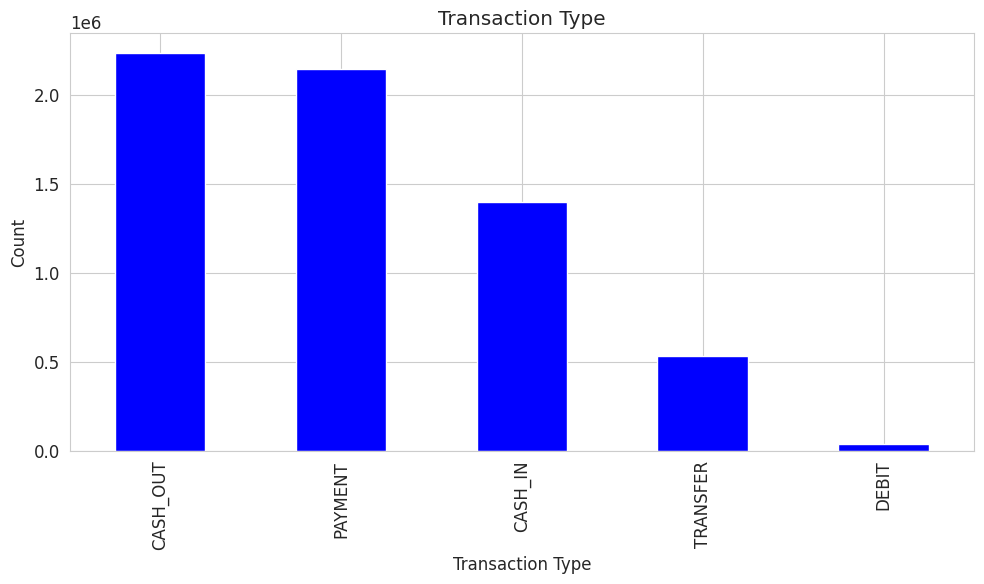

In [12]:
# Transaction Type Distribution
dataset['type'].value_counts().plot(
    kind='bar',
    title='Transaction Type',
    color='blue'
)

plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

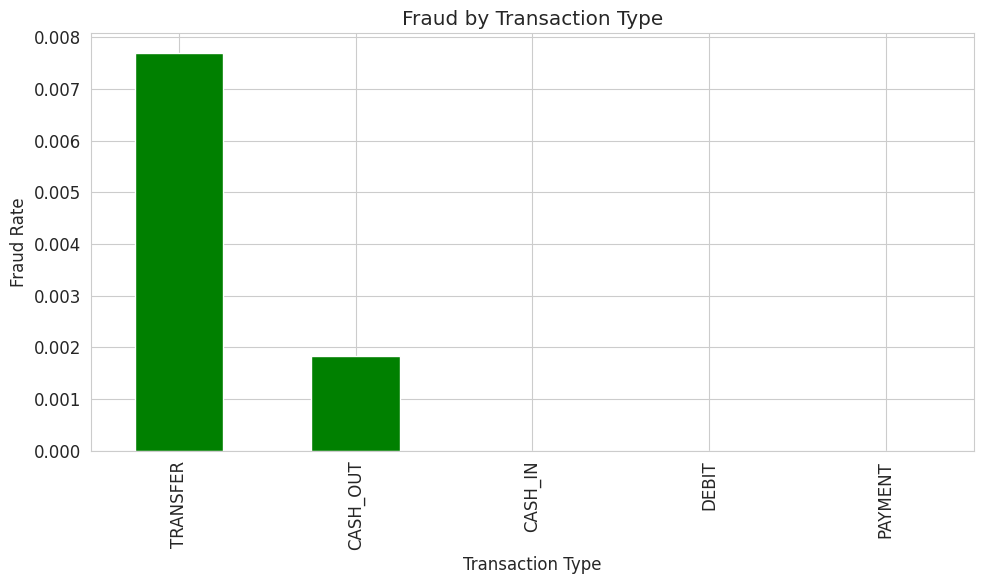

In [13]:
# Fraud Rate by Transaction Type
fraud_by_type = (
    dataset.groupby('type')['isFraud']
    .mean()
    .sort_values(ascending=False)
)

fraud_by_type.plot(
    kind='bar',
    title='Fraud by Transaction Type',
    color='green'
)

plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

In [14]:
# Statistical Summary of Transaction Amount
dataset['amount'].describe().astype(int)

,amount
count,6362620
mean,179861
std,603858
min,0
25%,13389
50%,74871
75%,208721
max,92445516


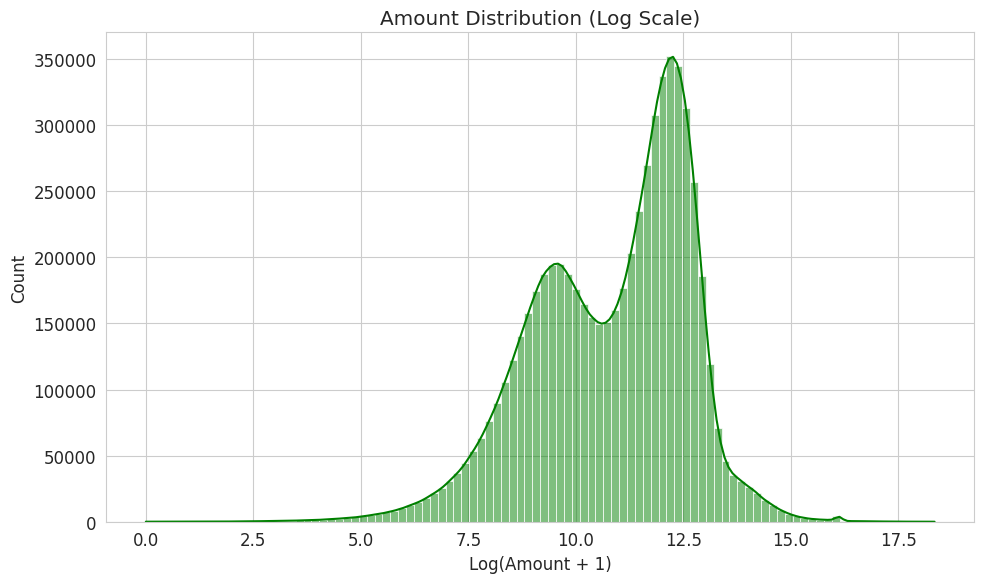

In [15]:
# Amount Distribution (Log Scale)

sns.histplot(
    np.log1p(dataset['amount']),
    kde=True,
    bins=100,
    color='green'
)

plt.title('Amount Distribution (Log Scale)')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

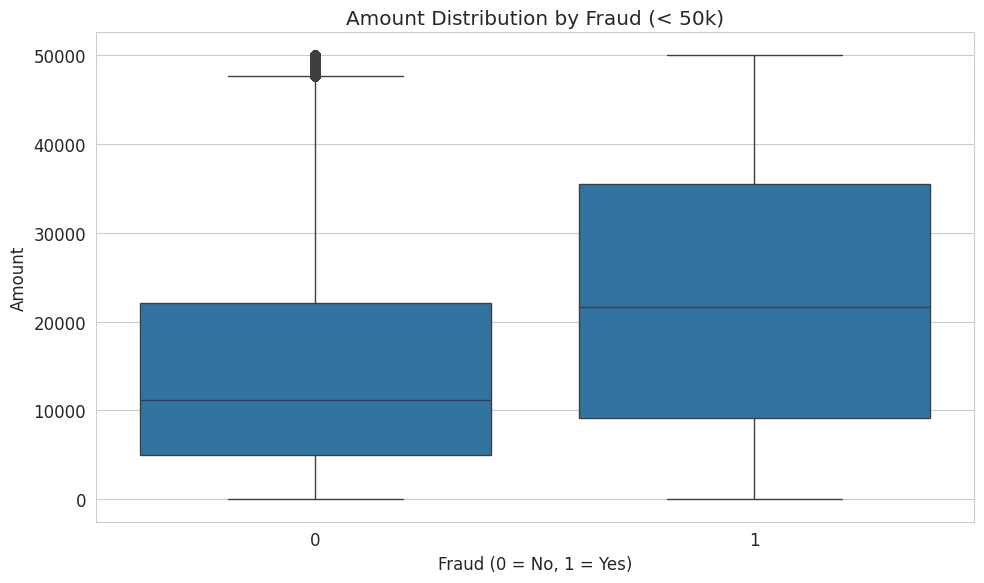

In [16]:
# Boxplot: Amount vs Fraud Status (Transactions < 50k)
filtered_data = dataset[dataset['amount'] < 50000]

sns.boxplot(
    data=filtered_data,
    x='isFraud',
    y='amount'
)

plt.title('Amount Distribution by Fraud (< 50k)')
plt.xlabel('Fraud (0 = No, 1 = Yes)')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

In [17]:
# Feature Engineering: Balance Difference Features

# Create new features only if not already present
if 'balanceDiffOriginal' not in dataset.columns:
    dataset['balanceDiffOriginal'] = (
        dataset['oldbalanceOrg'] - dataset['newbalanceOrig']
    )

if 'balanceDiffDest' not in dataset.columns:
    dataset['balanceDiffDest'] = (
        dataset['newbalanceDest'] - dataset['oldbalanceDest']
    )

# Preview updated columns
dataset[['balanceDiffOriginal', 'balanceDiffDest']].head()

,balanceDiffOriginal,balanceDiffDest
0,9839.64,0.0
1,1864.28,0.0
2,181.00,0.0
3,181.00,-21182.0
4,11668.14,0.0


In [18]:
# Count Negative Values in Sender Balance Difference
(dataset['balanceDiffOriginal'] < 0).sum()

np.int64(1399253)

In [19]:
# Count Negative Values in Destination Balance Difference
(dataset['balanceDiffDest'] < 0).sum()

np.int64(1238864)

In [20]:
# Display First 2 Rows After Feature Engineering
dataset.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


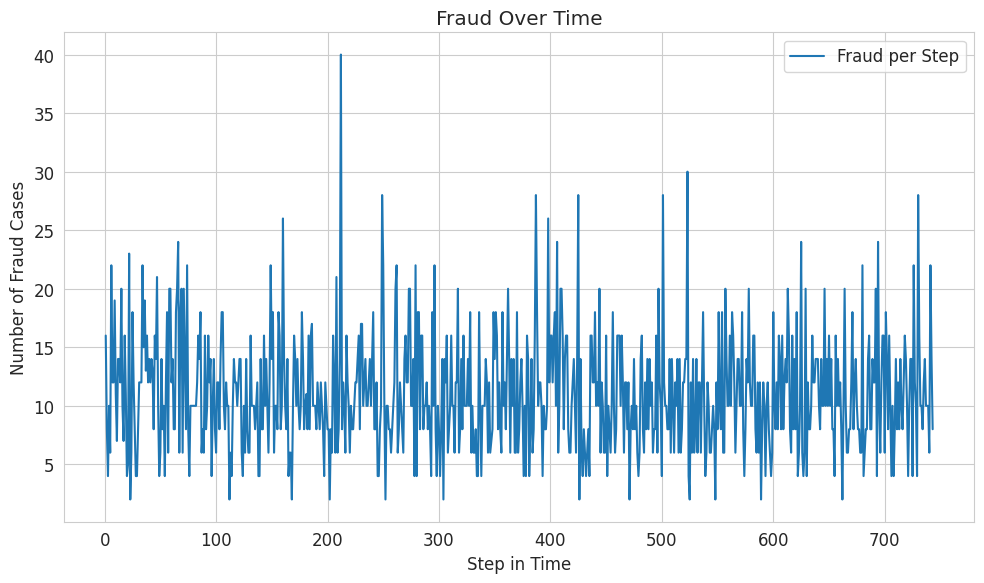

In [21]:
# Fraud Transactions Over Time
# Run only if 'step' column exists

if 'step' in dataset.columns:

    fraud_per_step = (
        dataset[dataset['isFraud'] == 1]['step']
        .value_counts()
        .sort_index()
    )

    plt.plot(
        fraud_per_step.index,
        fraud_per_step.values,
        label='Fraud per Step'
    )

    plt.xlabel('Step in Time')
    plt.ylabel('Number of Fraud Cases')
    plt.title('Fraud Over Time')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Column 'step' already removed from dataset.")

In [22]:
# Drop Unnecessary Column
dataset.drop(columns='step', inplace=True)

In [23]:
dataset.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [24]:
# Top 10 Most Frequent Sender Accounts
topSenders = dataset['nameOrig'].value_counts().head(10)
topSenders

,count
nameOrig,
C1530544995,3
C545315117,3
C724452879,3
C1784010646,3
C1677795071,3
C1462946854,3
C1065307291,3
C1999539787,3
C2098525306,3


In [25]:
topSenders

,count
nameOrig,
C1530544995,3
C545315117,3
C724452879,3
C1784010646,3
C1677795071,3
C1462946854,3
C1065307291,3
C1999539787,3
C2098525306,3


In [26]:
# Top 10 Most Frequent Receiver Accounts
topReceivers = dataset['nameDest'].value_counts().head(10)
topReceivers

,count
nameDest,
C1286084959,113
C985934102,109
C665576141,105
C2083562754,102
C248609774,101
C1590550415,101
C1789550256,99
C451111351,99
C1360767589,98


In [27]:
# Top 10 Sender Accounts Involved in Fraud
fraud_users = (
    dataset[dataset['isFraud'] == 1]['nameOrig']
    .value_counts()
    .head(10)
)

fraud_users

,count
nameOrig,
C1280323807,1
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
C1039979813,1
C2089752665,1
C1614818636,1
C40604503,1


In [28]:
fraud_users

,count
nameOrig,
C1280323807,1
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
C1039979813,1
C2089752665,1
C1614818636,1
C40604503,1


In [29]:
# Filter Only High-Risk Transaction Types

high_risk_data = dataset[
    dataset['type'].isin(['TRANSFER', 'CASH_OUT'])
].copy()

# Preview Data
high_risk_data.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [30]:
# Count of High-Risk Transaction Types

high_risk_data = dataset[
    dataset['type'].isin(['TRANSFER', 'CASH_OUT'])
].copy()

high_risk_data['type'].value_counts()

,count
type,
CASH_OUT,2237500
TRANSFER,532909


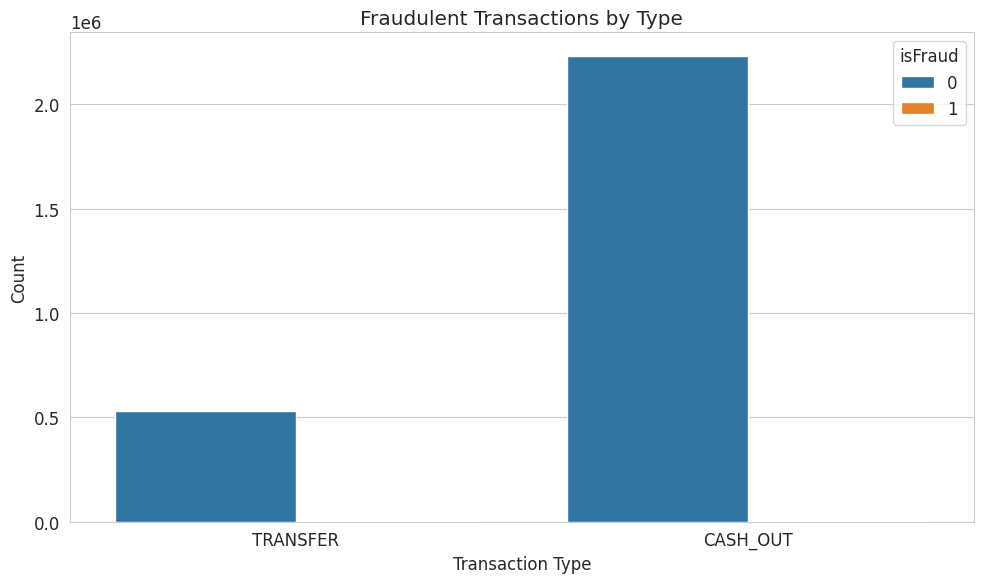

In [31]:
# Fraudulent Transactions by Transaction Type

sns.countplot(
    data=high_risk_data,
    x='type',
    hue='isFraud'
)

plt.title('Fraudulent Transactions by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [32]:
# Correlation Matrix for Numerical Features

corr = dataset[
    ['amount',
     'oldbalanceOrg',
     'newbalanceOrig',
     'oldbalanceDest',
     'newbalanceDest']
].corr()

corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000


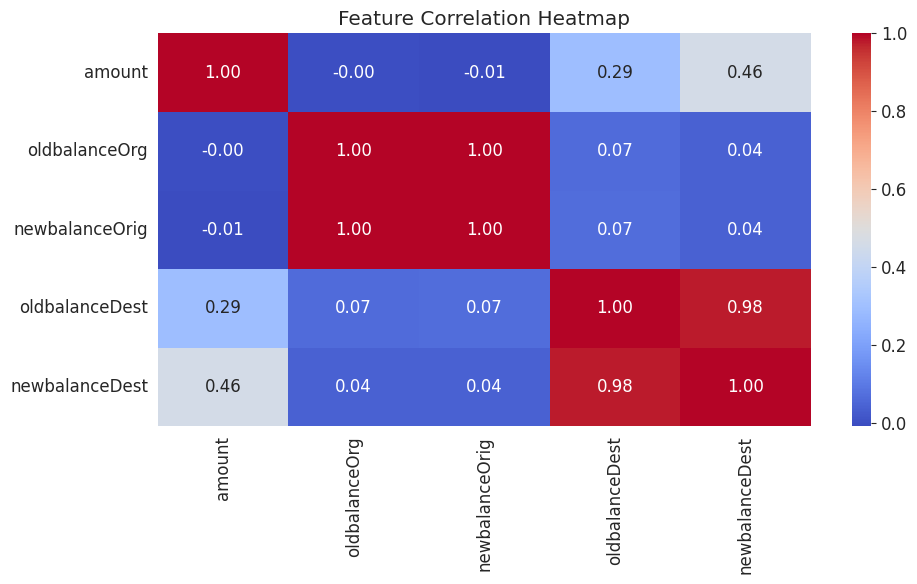

In [33]:
# Feature Correlation Heatmap

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [34]:
# Suspicious Cases: Sender Balance Becomes Zero After Transfer/Cash Out

zero_after_transfer = dataset[
    (dataset['oldbalanceOrg'] > 0) &
    (dataset['newbalanceOrig'] == 0) &
    (dataset['type'].isin(['TRANSFER', 'CASH_OUT']))
].copy()

zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [35]:
# Number of Suspicious Zero-Balance Transactions
len(zero_after_transfer)

1188074

In [36]:
# Class Distribution of Target Variable
dataset['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [37]:
# ==========================================================
# Feature Selection for Fraud Detection Model
# ==========================================================

# Input Features
X = dataset.drop(columns=['isFraud', 'nameOrig', 'nameDest'])

# Target Variable
y = dataset['isFraud']

print("Selected Features Shape:", X.shape)
print("Target Shape:", y.shape)

# Preview Features
X.head()

Selected Features Shape: (6362620, 9)
Target Shape: (6362620,)


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,balanceDiffOriginal,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,0,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,0,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [38]:

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [39]:
dataset.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [40]:
# Create Modeling Dataset
# Remove unnecessary identifier columns

df_model = dataset.drop(
    columns=['nameOrig', 'nameDest', 'isFlaggedFraud'],
    errors='ignore'   # avoids error if column already removed
)

# Preview Shape
print("Model Dataset Shape:", df_model.shape)
df_model.head()

Model Dataset Shape: (6362620, 9)


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOriginal,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [41]:
# Preview Modeling Dataset
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOriginal,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [42]:
# Define Feature Columns

categorical = ['type']

numeric = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'balanceDiffOriginal',
    'balanceDiffDest'
]

In [43]:
# Separate Features and Target Variable

y = df_model['isFraud']
X = df_model.drop(columns='isFraud')

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (6362620, 8)
Target Shape: (6362620,)


In [44]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (4453834, 8)
Test Shape : (1908786, 8)


In [45]:
# Data Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),                 # Scale numeric features
        ('cat', OneHotEncoder(drop='first',
                              handle_unknown='ignore'), categorical)  # Encode category
    ],
    remainder='drop'
)

In [46]:
# Logistic Regression Pipeline

lr_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

In [47]:
# Train Logistic Regression Model

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'balanceDiffOriginal',
                                                   'balanceDiffDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [48]:
# Predict on Test Data

y_pred = lr_pipeline.predict(X_test)

In [49]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [50]:
# Confusion Matrix

print(confusion_matrix(y_test, y_pred))

[[1805979  100343]
 [    150    2314]]


In [51]:
# Model Accuracy Score

lr_pipeline.score(X_test, y_test)

0.9473524009501327

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
# Random Forest Pipeline

rf_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [54]:
# Train Random Forest Model

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'balanceDiffOriginal',
                                                   'balanceDiffDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['type'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [55]:
y_pred_rf = rf_pipeline.predict(X_test)

In [56]:
# Random Forest Evaluation

print("Random Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# ROC AUC Score
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results
[[1906244      78]
 [    471    1993]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.96      0.81      0.88      2464

    accuracy                           1.00   1908786
   macro avg       0.98      0.90      0.94   1908786
weighted avg       1.00      1.00      1.00   1908786

ROC AUC: 0.9956724892984923


In [57]:
# Install Required Libraries (Run only once in Colab/Jupyter)

!pip install -q xgboost imbalanced-learn tensorflow

In [58]:
from imblearn.over_sampling import SMOTE

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (5090096, 8)
Test Shape : (1272524, 8)


In [60]:
# Preprocess Training and Test Data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Train Shape:", X_train_processed.shape)
print("Processed Test Shape :", X_test_processed.shape)

Processed Train Shape: (5090096, 11)
Processed Test Shape : (1272524, 11)


In [61]:
# Select Only Non-Fraud Transactions for Autoencoder Training

# Ensure scaled train data exists
if 'X_train_scaled' not in globals():
    X_train_scaled = preprocessor.fit_transform(X_train)

# Select genuine transactions only
X_train_nonfraud = X_train_scaled[y_train.values == 0]

print("Non-Fraud Training Shape:", X_train_nonfraud.shape)

Non-Fraud Training Shape: (5083526, 11)


In [62]:
# Final Clean Runtime Recovery Cell
# Recreates all required variables after kernel reset

# Duplicate imports removed if already loaded
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create modeling dataset
df_model = dataset.drop(
    columns=['nameOrig', 'nameDest', 'isFlaggedFraud'],
    errors='ignore'
)

# Features and Target
X = df_model.drop(columns='isFraud')
y = df_model['isFraud']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature columns
categorical = ['type']

numeric = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'balanceDiffOriginal',
    'balanceDiffDest'
]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ]
)

# Transform data
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print("Train Shape:", X_train_scaled.shape)
print("Test Shape :", X_test_scaled.shape)

Train Shape: (5090096, 12)
Test Shape : (1272524, 12)


In [63]:
# Select only genuine (non-fraud) transactions
X_train_nonfraud = X_train_scaled[y_train.values == 0]

# Convert sparse matrix to dense if needed
X_train_nonfraud = (
    X_train_nonfraud.toarray()
    if hasattr(X_train_nonfraud, "toarray")
    else X_train_nonfraud
)

# Input dimension
input_dim = X_train_nonfraud.shape[1]

# Autoencoder Architecture
input_layer = Input(shape=(input_dim,))

encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)

decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

# Build Model
autoencoder = Model(inputs=input_layer, outputs=decoded)

# Compile
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

# Train Model
history = autoencoder.fit(
    X_train_nonfraud,
    X_train_nonfraud,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_split=0.10,
    verbose=1
)

Epoch 1/10
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 66s 4ms/step - loss: 0.0063 - val_loss: 9.3060e-05
Epoch 2/10
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 1.4289e-04 - val_loss: 1.6556e-04
Epoch 3/10
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 1.1064e-04 - val_loss: 1.3145e-05
Epoch 4/10
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 1.2226e-04 - val_loss: 1.3227e-05
Epoch 5/10
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 1.2074e-04 - val_loss: 1.8441e-04
Epoch 6/10
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 1.0133e-04 - val_loss: 1.5353e-05
Epoch 7/10
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 1.3395e-04 - val_loss: 4.1789e-05
Epoch 8/10
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 9.2062e-05 - val_loss: 0.0045
Epoch 9/10
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - loss: 1.1078e-04 - val_loss: 1.3602e-05
Epoch 10/10
17872/17872 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 8.2278e-05 - val_loss: 1.3488e-05


In [64]:
# Prepare Data + Apply SMOTE (Training Set Only)

# Duplicate preprocessing avoided if already created
if 'X_train_scaled' not in globals():
    X_train_scaled = preprocessor.fit_transform(X_train)
    X_test_scaled = preprocessor.transform(X_test)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original Train Shape :", X_train_scaled.shape)
print("SMOTE Train Shape    :", X_train_smote.shape)

Original Train Shape : (5090096, 12)
SMOTE Train Shape    : (10167052, 12)


In [65]:
# Class Distribution Before and After SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

After SMOTE:
isFraud
0    5083526
1    5083526
Name: count, dtype: int64


In [66]:
# Hybrid Model Part 2: XGBoost Training

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.10,
    scale_pos_weight=1,      # SMOTE already balanced classes
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [67]:
# Evaluate XGBoost Model

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.28      0.99      0.44      1643

    accuracy                           1.00   1272524
   macro avg       0.64      1.00      0.72   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC AUC: 0.9993721506660264


In [68]:
# # Create Hybrid Features First (Autoencoder + Original Features)

# # Convert sparse matrices to dense if needed
# X_train_dense = (
#     X_train_smote.toarray()
#     if hasattr(X_train_smote, "toarray")
#     else X_train_smote
# )

# X_test_dense = (
#     X_test_scaled.toarray()
#     if hasattr(X_test_scaled, "toarray")
#     else X_test_scaled
# )

# # Generate encoded features using trained autoencoder encoder part
# encoder = Model(
#     inputs=autoencoder.input,
#     outputs=autoencoder.layers[2].output   # bottleneck layer
# )

# encoded_train = encoder.predict(X_train_dense)
# encoded_test = encoder.predict(X_test_dense)

# # Combine original + encoded features
# X_train_hybrid = np.hstack((X_train_dense, encoded_train))
# X_test_hybrid = np.hstack((X_test_dense, encoded_test))

# print("Hybrid Train Shape:", X_train_hybrid.shape)
# print("Hybrid Test Shape :", X_test_hybrid.shape)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
2              XGBoost  0.996763   0.284321  0.993305  0.442097  0.999372
0  Logistic Regression  0.947160   0.022563  0.943396  0.044072  0.990061
1        Random Forest  0.998731   1.000000  0.017042  0.033513  0.864899


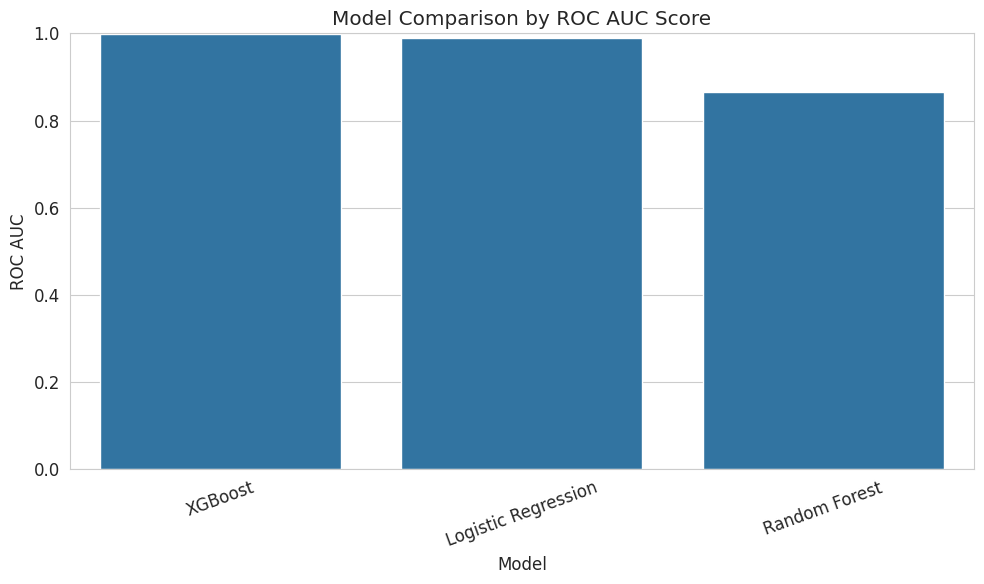

In [71]:
# ==========================================================
# COMPARE ALL MODELS + VISUALIZE RESULTS
# Logistic Regression, Random Forest, XGBoost, Hybrid AE+XGB
# ==========================================================

# Required metrics (import only if not already imported)
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = []

# ==========================================================
# 1. Logistic Regression
# ==========================================================
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "Recall": recall_score(y_test, y_pred_lr, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_lr, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_prob_lr)
})

# ==========================================================
# 2. Random Forest
# ==========================================================
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_rf, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_prob_rf)
})

# ==========================================================
# 3. XGBoost
# ==========================================================
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb, zero_division=0),
    "Recall": recall_score(y_test, y_pred_xgb, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_xgb, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_prob_xgb)
})

# ==========================================================
# 4. Hybrid Model
# ==========================================================
if 'hybrid_model' in globals() and 'X_test_hybrid' in globals():

    y_pred_hybrid = hybrid_model.predict(X_test_hybrid)
    y_prob_hybrid = hybrid_model.predict_proba(X_test_hybrid)[:, 1]

    results.append({
        "Model": "Hybrid AE + XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_hybrid),
        "Precision": precision_score(y_test, y_pred_hybrid, zero_division=0),
        "Recall": recall_score(y_test, y_pred_hybrid, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_hybrid, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_prob_hybrid)
    })

# ==========================================================
# Final Comparison Table
# ==========================================================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC AUC", ascending=False)

print(results_df)

# ==========================================================
# Visualization
# ==========================================================
plt.figure(figsize=(10,6))

sns.barplot(data=results_df, x="Model", y="ROC AUC")

plt.title("Model Comparison by ROC AUC Score")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.tight_layout()
plt.show()

FINAL MODEL RESULTS
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0              XGBoost  0.996763   0.284321  0.993305  0.442097  0.999372
1  Logistic Regression  0.947160   0.022563  0.943396  0.044072  0.990061
2        Random Forest  0.998731   1.000000  0.017042  0.033513  0.864899

Best Model:
Model         XGBoost
Accuracy     0.996763
Precision    0.284321
Recall       0.993305
F1 Score     0.442097
ROC AUC      0.999372
Name: 0, dtype: object


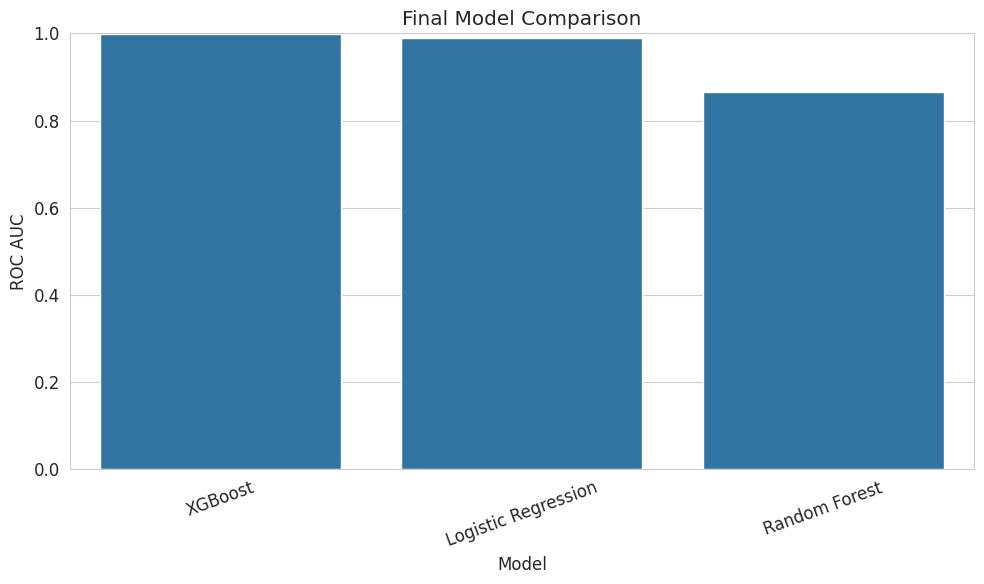

In [79]:
# ==========================================================
# FINAL MODEL RESULT (Best Performing Model)
# Automatically Selects Best Model by ROC AUC
# ==========================================================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

results = []

# ----------------------------------------------------------
# Logistic Regression
# ----------------------------------------------------------
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:,1]

results.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr, zero_division=0),
    recall_score(y_test, y_pred_lr, zero_division=0),
    f1_score(y_test, y_pred_lr, zero_division=0),
    roc_auc_score(y_test, y_prob_lr)
])

# ----------------------------------------------------------
# Random Forest
# ----------------------------------------------------------
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

results.append([
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf, zero_division=0),
    recall_score(y_test, y_pred_rf, zero_division=0),
    f1_score(y_test, y_pred_rf, zero_division=0),
    roc_auc_score(y_test, y_prob_rf)
])

# ----------------------------------------------------------
# XGBoost
# ----------------------------------------------------------
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:,1]

results.append([
    "XGBoost",
    accuracy_score(y_test, y_pred_xgb),
    precision_score(y_test, y_pred_xgb, zero_division=0),
    recall_score(y_test, y_pred_xgb, zero_division=0),
    f1_score(y_test, y_pred_xgb, zero_division=0),
    roc_auc_score(y_test, y_prob_xgb)
])

# ----------------------------------------------------------
# Hybrid Model (if available)
# ----------------------------------------------------------
if 'hybrid_model' in globals() and 'X_test_hybrid' in globals():

    y_pred_hybrid = hybrid_model.predict(X_test_hybrid)
    y_prob_hybrid = hybrid_model.predict_proba(X_test_hybrid)[:,1]

    results.append([
        "Hybrid AE + XGBoost",
        accuracy_score(y_test, y_pred_hybrid),
        precision_score(y_test, y_pred_hybrid, zero_division=0),
        recall_score(y_test, y_pred_hybrid, zero_division=0),
        f1_score(y_test, y_pred_hybrid, zero_division=0),
        roc_auc_score(y_test, y_prob_hybrid)
    ])

# ----------------------------------------------------------
# Create DataFrame
# ----------------------------------------------------------
columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

results_df = pd.DataFrame(results, columns=columns)

# Best Model
best_model = results_df.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

print("FINAL MODEL RESULTS")
print(best_model)

print("\nBest Model:")
print(best_model.iloc[0])

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

sns.barplot(
    data=best_model,
    x="Model",
    y="ROC AUC"
)

plt.title("Final Model Comparison")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.tight_layout()
plt.show()

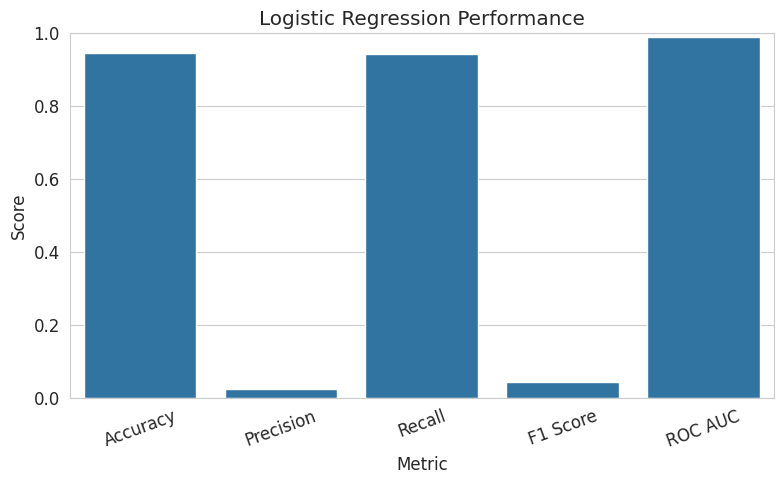

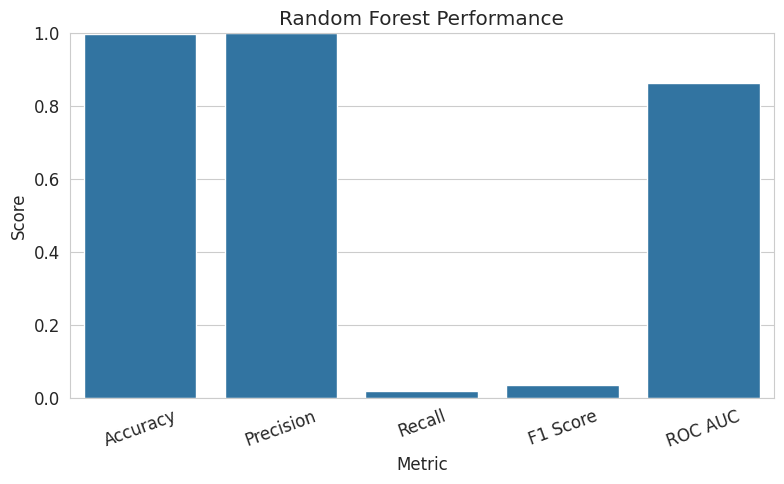

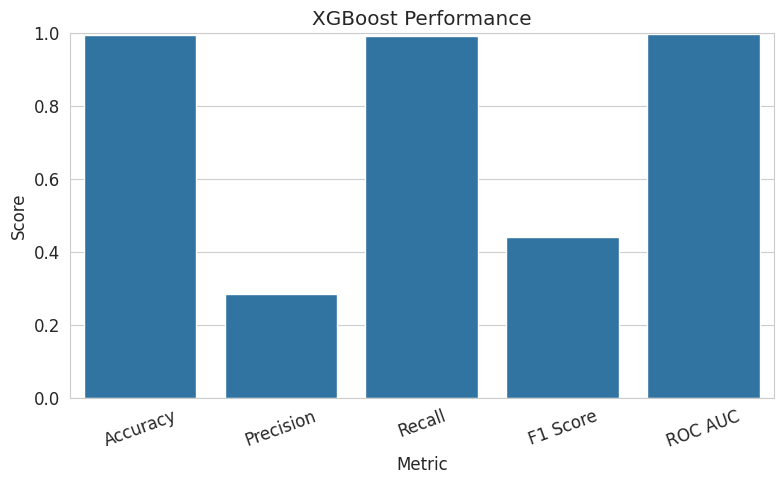

In [75]:
# ==========================================================
# VISUALIZE EVERY MODEL PERFORMANCE SEPARATELY
# Logistic Regression, Random Forest, XGBoost, Hybrid AE+XGB
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# ----------------------------------------------------------
# Function to Draw Single Model Graph
# ----------------------------------------------------------
def plot_model_metrics(model_name, y_true, y_pred, y_prob):

    from sklearn.metrics import accuracy_score, precision_score
    from sklearn.metrics import recall_score, f1_score, roc_auc_score

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }

    metric_df = pd.DataFrame({
        "Metric": list(metrics.keys()),
        "Score": list(metrics.values())
    })

    plt.figure(figsize=(8,5))
    sns.barplot(data=metric_df, x="Metric", y="Score")
    plt.title(f"{model_name} Performance")
    plt.ylim(0,1)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# ==========================================================
# 1. Logistic Regression
# ==========================================================
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:,1]

plot_model_metrics(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)

# ==========================================================
# 2. Random Forest
# ==========================================================
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

plot_model_metrics(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

# ==========================================================
# 3. XGBoost
# ==========================================================
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:,1]

plot_model_metrics(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

# ==========================================================
# 4. Hybrid AE + XGBoost (Optional)
# ==========================================================
if 'hybrid_model' in globals() and 'X_test_hybrid' in globals():

    y_pred_hybrid = hybrid_model.predict(X_test_hybrid)
    y_prob_hybrid = hybrid_model.predict_proba(X_test_hybrid)[:,1]

    plot_model_metrics(
        "Hybrid AE + XGBoost",
        y_test,
        y_pred_hybrid,
        y_prob_hybrid
    )

In [76]:
import joblib
joblib.dump(xgb, "xgboost_model.pkl")
joblib.dump(rf_pipeline, "random_forest.pkl")
joblib.dump(lr_pipeline, "logistic_model.pkl")

['logistic_model.pkl']

In [78]:
autoencoder.save("autoencoder_model.h5")